# 03 — Commits per Hour: Working Days vs Weekends

## What this notebook does

Analyzes at what hours of the day students were most active submitting
work, comparing working days and weekends separately.

## Data

- **Source:** `checking-logs.sqlite` → table `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`)
- **Aggregation:** average number of commits per hour, split by day type

## Key steps

1. Query checker timestamps via SQL
2. Extract hour and day of week from timestamp
3. Label each day as `working_day` or `weekend`
4. Group by date + day type + hour, count commits per group
5. Calculate average commits per hour across all dates
6. Pivot the result and plot two bar charts side by side (subplots)

## Result

Two bar charts — one for working days, one for weekends — showing average
commit activity by hour. Peak activity on working days is at **21:00**,
on weekends at **11:00**, revealing different study patterns depending
on the day type.

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
df = pd.io.sql.read_sql("""
                     SELECT c.timestamp
                     FROM checker AS c
                     WHERE c.uid LIKE 'user_%'
                     """,
                     conn,
                     parse_dates=['timestamp'])
df.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
day_of_week = df['timestamp'].dt.day_of_week
hour = df['timestamp'].dt.hour

df['day_of_week'] = day_of_week
df['hour'] = hour

df['day_of_week'] = df['day_of_week'].apply(lambda x: 'weekend' if (x == 5 or x==6) else 'working_day')
df.head()



,timestamp,day_of_week,hour
0,2020-04-17 05:19:02.744528,working_day,5
1,2020-04-17 05:22:35.249331,working_day,5
2,2020-04-17 05:22:45.549397,working_day,5
3,2020-04-17 05:34:14.691200,working_day,5
4,2020-04-17 05:34:24.422370,working_day,5


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
date = df['timestamp'].dt.date
df['timestamp'] = date

commits_per_day = df.groupby(['timestamp', 'day_of_week', 'hour' ]).size().reset_index(name='commits')
commits_per_day.head()

,timestamp,day_of_week,hour,commits
0,2020-04-17,working_day,5,13
1,2020-04-17,working_day,11,8
2,2020-04-17,working_day,12,2
3,2020-04-18,weekend,7,1
4,2020-04-18,weekend,13,5


In [9]:
avg_commits = commits_per_day.groupby(['day_of_week', 'hour'])['commits'].mean().reset_index(name='commits')
avg_commits[avg_commits['hour'] == 17]

,day_of_week,hour,commits
14,weekend,17,7.142857
35,working_day,17,16.000000


In [6]:
avg = avg_commits.pivot(index='hour', columns=['day_of_week'], values='commits')

array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

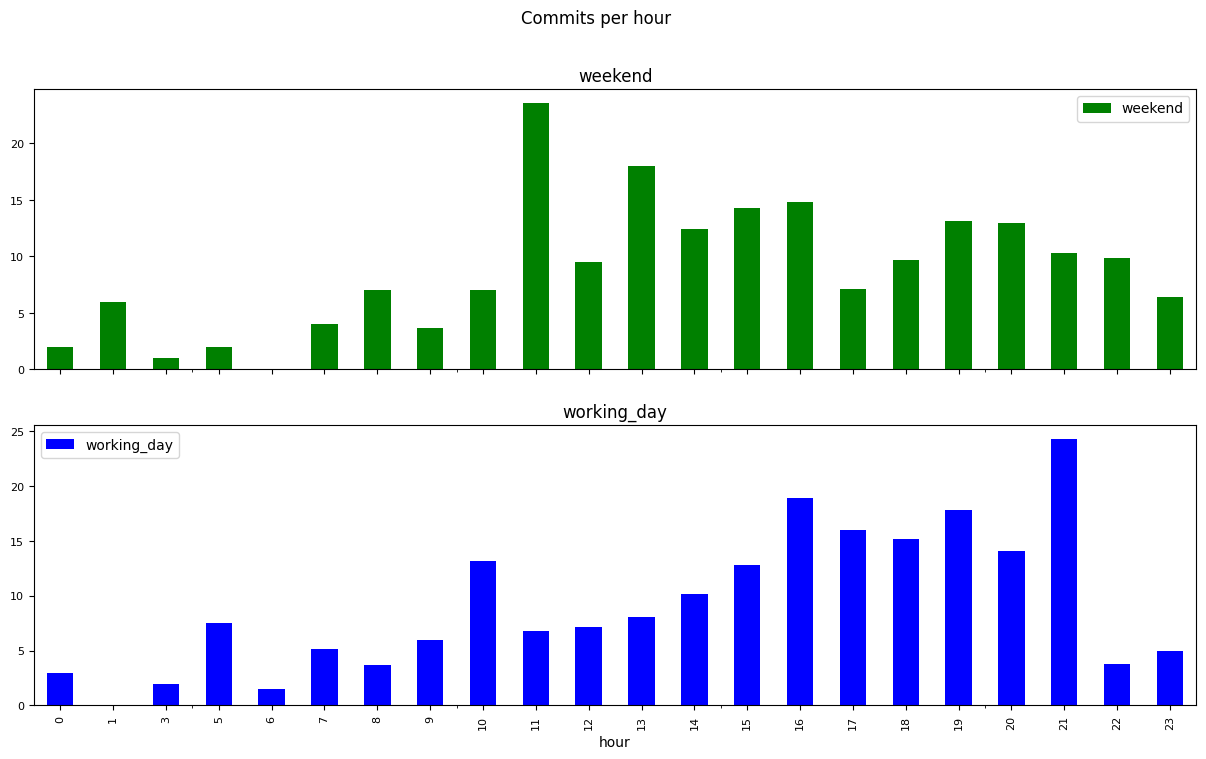

In [7]:
avg.plot(kind='bar', subplots=True, figsize=(15,8), fontsize=8, color=['green', 'blue'], title='Commits per hour')

In [8]:
conn.close()